# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Ayesha Noor

**Roll Number:** 023-24-0023

**GitHub Repository:** https://github.com/Ayesha-Mangi/ML_Labs

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [61]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("telco_churn.csv")   # update path/filename if different
df.shape
# df.head()




(7043, 21)

---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**

The company wants to understand why some customers leave its services and which factors may be related to customer churn. The target variable is likely Churn, because it shows whether a customer left the company (Yes) or stayed (No).

**Answer 2:**

Useful predictors:

Contract - The type of contract may affect how likely a customer is to leave the company.

tenure - It shows how long a customer has been with the company, which may be related to churn.

MonthlyCharges - Customers with higher monthly charges may be more likely to leave.

InternetService - Different internet services may have different customer churn rates.

PaymentMethod - The payment method may be related to customer convenience and churn.

Useless predictors:

customerID - It only identifies the customer and does not provide useful information about their behavior.

gender - Gender alone does not give much useful information about why a customer would leave the company.

**Answer 3:**
1) Do customers with month-to-month contracts churn more than customers with longer contracts?
2) Are customers with higher monthly charges more likely to churn?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [62]:
# Task 4 — dataset shape, column names, data types
df.shape
# there are 7043 customers 
# total 21 columns_ 20 features and 1 target column

df.dtypes

# The dataset contains 7,043 customers and 21 columns, including 20 features and 1 target variable (Churn). The numerical features are SeniorCitizen, tenure, and MonthlyCharges, while TotalCharges represents numerical values but is currently stored as a string. The remaining features are categorical, with SeniorCitizen being a binary variable represented by 0 and 1.




customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [63]:
# Task 5 — identify identifier columns / wrong data types
df.info()

# customerID is simply an identifier because it is used only to identify each customer and does not provide useful information for predicting churn. 
# TotalCharges has a string data type, but it represents numerical charge amounts, so it should be treated as a numerical column.


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [64]:
# Task 6 — unique values in 3 categorical columns
df["PhoneService"].unique()

# PhoneService has two unique values: Yes and No. 

df["Contract"].unique()
# Contract has three unique values: Month-to-month, One year, and Two year. 

df["PaymentMethod"].unique()

# PaymentMethod has four unique values: Electronic check, Mailed check, Bank transfer (automatic), and Credit card (automatic). 

# None of these columns contain unexpected or inconsistent categories.

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)

The dataset contains 7,043 customers and 21 columns, including 20 features and 1 target variable (Churn). The numerical features include SeniorCitizen, tenure, and MonthlyCharges, while TotalCharges represents numerical values but is currently stored as a string. The customerID column is an identifier rather than a predictive feature. The categorical columns contain meaningful and consistent categories, with no obvious unexpected values found in the three columns checked.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [65]:
# Task 7 — missing values: count and percentage per column
df.isnull().sum()

df.isnull().mean() * 100

(df["TotalCharges"].str.strip() == "").sum()

(11 / len(df)) * 100

df[df["TotalCharges"].str.strip() == ""]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [66]:
# Task 8 — duplicate rows vs duplicate IDs

df.duplicated().sum()

df["customerID"].duplicated().sum()


np.int64(0)

In [67]:
# Task 9 — investigate a suspicious / invalid value
# df["TotalCharges"].value_counts().tail(20)
# df["MultipleLines"].unique()
# df["OnlineSecurity"].unique()
# df["InternetService"].unique()
# df["PaymentMethod"].unique()
# df.describe()
categorical_cols = df.select_dtypes(include="str").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

**Answer 7 (which missing-value problems need action, and why):**

There are no actual NaN missing values in the dataset. However, I found 11 blank values in the TotalCharges column, which is about 0.15% of the total customers. These values require action because TotalCharges represents numerical amounts, and blank values can cause problems during calculations and analysis. The other columns do not have missing-value problems that require action.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**

There are no duplicate rows and no duplicate customer IDs in the dataset, as both checks returned 0. These are different issues because duplicate rows mean the entire record is repeated, while duplicate customer IDs mean the same customer identifier appears more than once.

**Answer 9 (suspicious value found and how):**

I found 11 blank values in the TotalCharges column. I found them by checking for empty strings after removing extra spaces. These values are suspicious because TotalCharges should contain numerical charge amounts, but some records contain blank values instead.


---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

In [68]:
df.loc[df["TotalCharges"].str.strip() == "", 
       ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Task 10 — Cleaning Decision Log**

<!-- | Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _e.g. TotalCharges stored as text_ | _..._ | _..._ | _..._ |
| _..._ | _..._ | _..._ | _..._ |
| _..._ | _..._ | _..._ | _..._ | -->

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` is stored as text | Convert it to numeric | `pd.to_numeric()` | It contains charge amounts, so it should be numeric. |
| 11 blank values in `TotalCharges` | Replace them with 0 | `replace()` | All 11 customers have `tenure = 0`, so their total charges can be 0. |
| Duplicate rows | No action | `df.duplicated()` | No duplicate rows were found. |
| Duplicate customer IDs | No action | `df["customerID"].duplicated()` | No duplicate customer IDs were found. |

In [69]:
# Task 11 — apply your cleaning decisions here
cleaned_df = df.copy()
cleaned_df["TotalCharges"] = cleaned_df["TotalCharges"].str.strip()
cleaned_df["TotalCharges"] = cleaned_df["TotalCharges"].replace("", "0")
cleaned_df["TotalCharges"] = pd.to_numeric(cleaned_df["TotalCharges"])

In [70]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
cleaned_df.info()
cleaned_df.isnull().sum()
cleaned_df.dtypes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

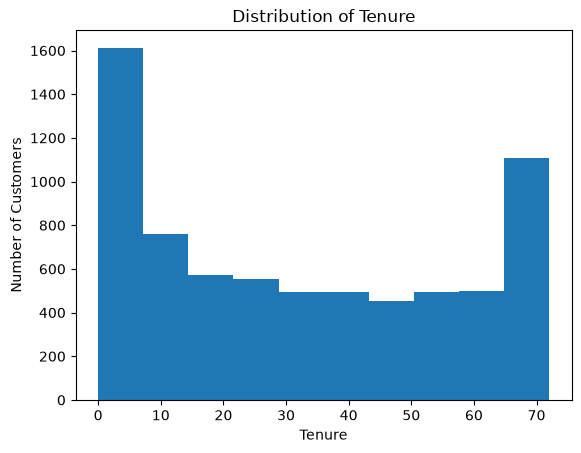

In [71]:
# Task 12 — numerical feature 1: distribution plot
import matplotlib.pyplot as plt
plt.hist(cleaned_df["tenure"])
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.title("Distribution of Tenure")
plt.show()

**Observation:** 

Most customers have either very low tenure or high tenure. The customers are spread across different tenure periods.


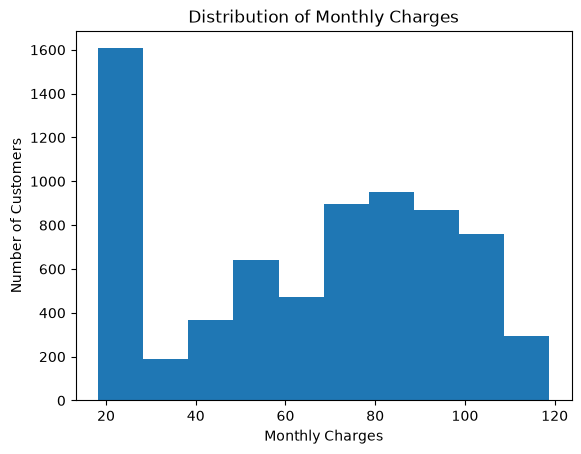

In [72]:
# Task 12 — numerical feature 2: distribution plot
plt.hist(cleaned_df["MonthlyCharges"])
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

**Observation:** _(what did you learn from this chart?)_

Monthly charges vary widely, with many customers having low charges around 20. A large number of customers also have charges between 70 and 100.



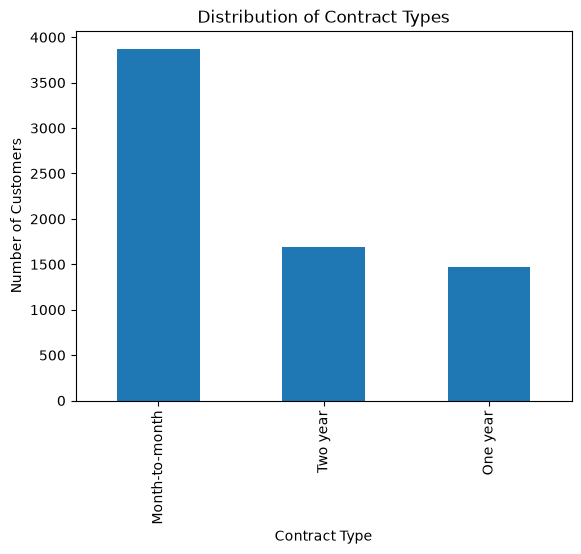

In [73]:
# Task 12 — categorical feature 1: distribution plot
cleaned_df["Contract"].value_counts().plot(kind="bar")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Distribution of Contract Types")
plt.show()

**Observation:** _(what did you learn from this chart?)_

Most customers have a month-to-month contract. One-year and two-year contracts have much fewer customers.

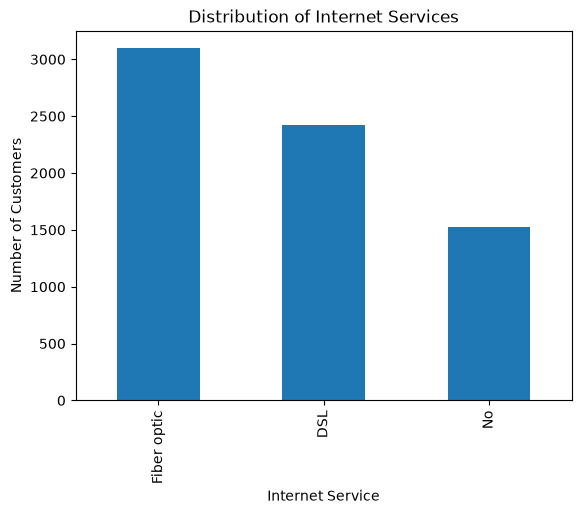

In [74]:
# Task 12 — categorical feature 2: distribution plot
cleaned_df["InternetService"].value_counts().plot(kind="bar")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Distribution of Internet Services")
plt.show()

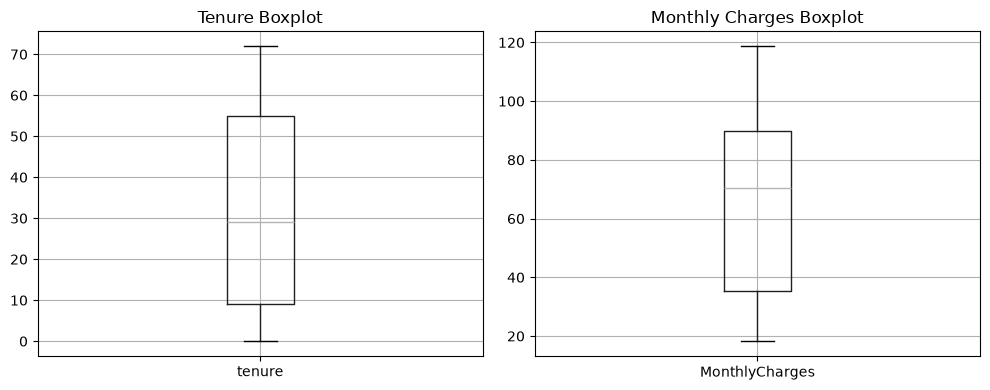

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cleaned_df.boxplot(column="tenure", ax=axes[0])
axes[0].set_title("Tenure Boxplot")

cleaned_df.boxplot(column="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges Boxplot")


plt.tight_layout()
plt.show()

**Observation:**

Fiber optic is the most common internet service among customers, followed by DSL. A smaller number of customers do not have internet service.

**Answer 13 (outliers / skew and possible explanation):**

TotalCharges is right-skewed because customers with longer tenure usually have higher total charges. Tenure and MonthlyCharges do not show strong skewness or extreme outliers. The differences mostly represent real differences between customers, such as new and long-term customers or low-cost and high-cost plans.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [76]:
# # Task 14 — churn counts and percentages
cleaned_df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**Answer 14 (balanced or imbalanced?):**

Non-churned customers (No): 5,174 (73.46%)
Churned customers (Yes): 1,869 (26.54%)

The Churn target variable is imbalanced, because the number of non-churned customers is much higher than the number of churned customers.

**Answer 15 (why imbalance might matter later):**

Class imbalance matters because a model may become biased toward the majority class and perform poorly at identifying the minority class. Also, accuracy alone can give a misleading impression of model performance when one class is much more common than the other.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

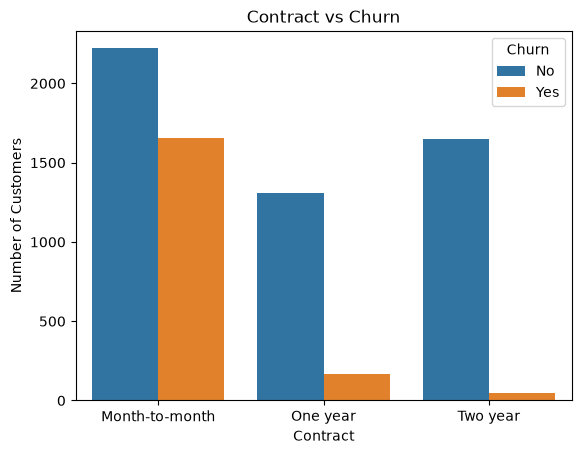

In [77]:
# Task 16 — categorical feature 1 vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract vs Churn')
plt.xlabel('Contract')
plt.ylabel('Number of Customers')
plt.show()

**Observation:** Month-to-month customers have a much higher churn rate than customers on one-year or two-year contracts.

**Evidence:** The within-contract churn percentages printed above show the highest `Yes` percentage for `Month-to-month`, while `Two year` has the lowest churn percentage.

**Possible Explanation:** Month-to-month contracts give customers more flexibility to leave, while longer contracts create more commitment and may reduce switching.


Churn percentage within each internet-service type:
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


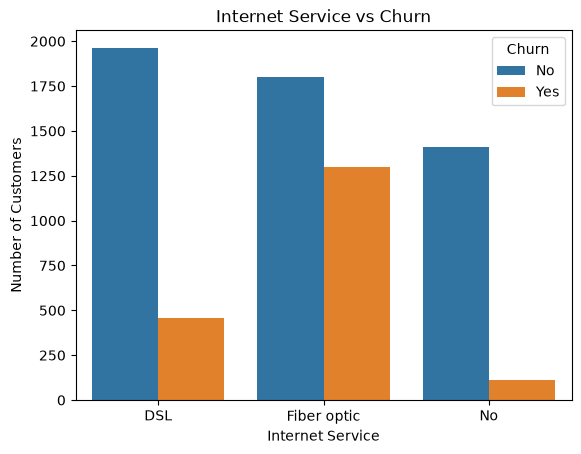

In [78]:
# Task 16 — categorical feature 2 vs Churn
internet_churn = pd.crosstab(
    cleaned_df["InternetService"],
    cleaned_df["Churn"],
    normalize="index"
) * 100

print("Churn percentage within each internet-service type:")
print(internet_churn.round(2))

sns.countplot(x="InternetService", hue="Churn", data=cleaned_df)
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()


**Observation:** Fiber-optic customers show a noticeably higher churn rate than DSL customers, while customers with no internet service have the lowest churn rate.

**Evidence:** The within-category churn percentages printed above allow the churn rate to be compared fairly across the three internet-service groups.

**Possible Explanation:** Fiber-optic service may be more expensive or may have stronger customer expectations, so dissatisfaction or price sensitivity could contribute to higher churn. This is an association, not proof that the service itself causes churn.

       count   mean  median
Churn                      
No      5174  37.57    38.0
Yes     1869  17.98    10.0


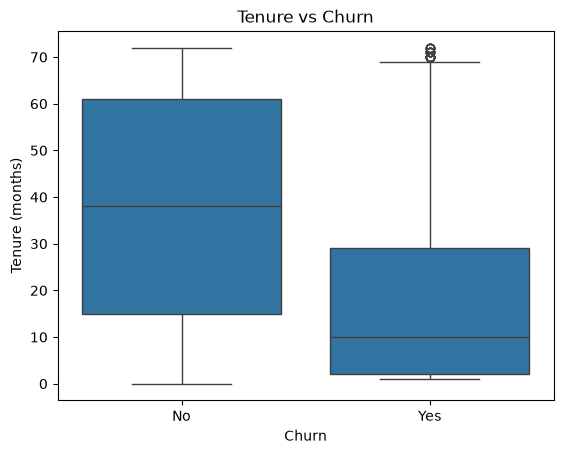

In [79]:
# Task 17 — numerical feature 1 vs Churn
print(cleaned_df.groupby("Churn")["tenure"].agg(["count", "mean", "median"]).round(2))

sns.boxplot(x="Churn", y="tenure", data=cleaned_df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()


**Observation:** Customers who churn generally have lower tenure than customers who stay.

**Evidence:** The group summary above compares the mean and median tenure for `Churn = Yes` and `Churn = No`; the churned group has the lower central values.

**Possible Explanation:** Newer customers may have had less time to become loyal and may be more willing to switch providers.

       count   mean  median
Churn                      
No      5174  61.27   64.43
Yes     1869  74.44   79.65


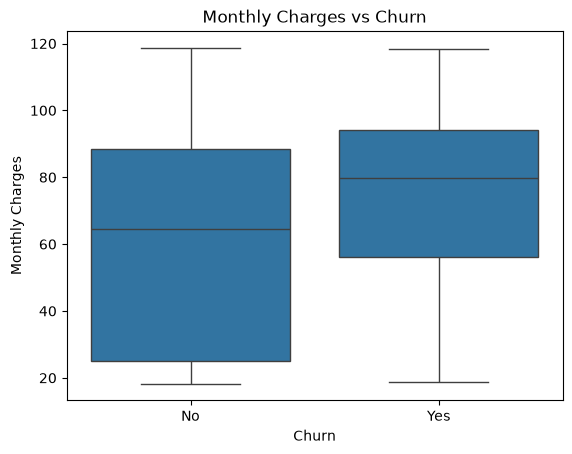

In [80]:
# Task 17 — numerical feature 2 vs Churn
print(cleaned_df.groupby("Churn")["MonthlyCharges"].agg(["count", "mean", "median"]).round(2))

sns.boxplot(x="Churn", y="MonthlyCharges", data=cleaned_df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


**Observation:** Churned customers tend to have higher monthly charges than customers who stay.

**Evidence:** The group summary above compares the mean and median `MonthlyCharges` for the two churn classes; the churned group has higher central values.

**Possible Explanation:** Higher monthly charges may increase price sensitivity or reflect service packages that customers are less satisfied with. Again, this relationship does not establish causation.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen           1.000   0.017           0.220         0.103
tenure                  0.017   1.000           0.248         0.826
MonthlyCharges          0.220   0.248           1.000         0.651
TotalCharges            0.103   0.826           0.651         1.000


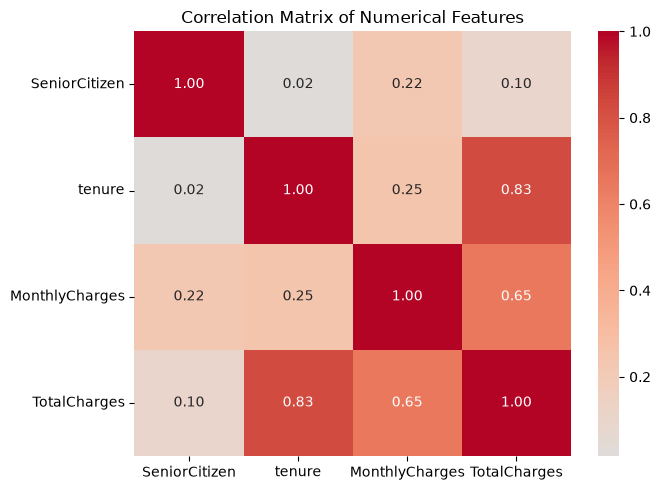

In [81]:
# Task 18 — correlation matrix and heatmap

numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
corr_matrix = cleaned_df[numeric_cols].corr()

print(corr_matrix.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()



**Answer 18 (most correlated pairs):**

The strongest relationship is between `tenure` and `TotalCharges`, because total charges accumulate as customers stay longer. `MonthlyCharges` and `TotalCharges` also show a positive relationship. `tenure` and `MonthlyCharges` have a much weaker positive relationship. The exact correlation values are printed by the code above.

**Answer 19 (correlation vs. causation; potential problems):**

Correlation does not imply causation: two variables can move together because of a shared underlying factor. `tenure` and `TotalCharges` are highly related, so including both can introduce redundancy or multicollinearity in some future models; however, whether this actually harms performance depends on the model and preprocessing.


---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**

- `customerID`: This is a pure identifier. It uniquely identifies customers but has no meaningful customer-behavior information and should not be used as a predictive feature.
- `TotalCharges`: This is not necessarily leakage, because it can represent charges accumulated up to the current observation. However, it should only be used if it would genuinely be available at the prediction time.
- `Churn`: This is the target itself, so it must never be included among the model input features.

**Answer 21 (what would go wrong):**

If the target or information unavailable at prediction time were included as an input, the model could learn information that would not actually be available when making a real prediction. This causes data leakage and can make validation performance look unrealistically strong while failing in real-world use.


---

## Part 10 — ML-Readiness Checklist

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique identifier; no useful predictive meaning. |
| gender | Categorical | Feature | Keep | Customer attribute that may contain predictive information. |
| SeniorCitizen | Numerical/binary | Feature | Keep | Binary customer attribute; can be used as a feature. |
| Partner | Categorical | Feature | Keep | Indicates relationship status and may relate to churn. |
| Dependents | Categorical | Feature | Keep | Indicates dependent status and may relate to churn. |
| tenure | Numerical | Feature | Keep | Measures customer duration with the company. |
| PhoneService | Categorical | Feature | Keep | Describes subscribed service. |
| MultipleLines | Categorical | Feature | Keep | Describes phone-line service level. |
| InternetService | Categorical | Feature | Keep | Service type is associated with different churn patterns. |
| OnlineSecurity | Categorical | Feature | Keep | Service subscription may relate to churn. |
| OnlineBackup | Categorical | Feature | Keep | Service subscription may relate to churn. |
| DeviceProtection | Categorical | Feature | Keep | Service subscription may relate to churn. |
| TechSupport | Categorical | Feature | Keep | Support subscription may relate to churn. |
| StreamingTV | Categorical | Feature | Keep | Service subscription may relate to churn. |
| StreamingMovies | Categorical | Feature | Keep | Service subscription may relate to churn. |
| Contract | Categorical | Feature | Keep | Contract length has a strong relationship with churn. |
| PaperlessBilling | Categorical | Feature | Keep | Billing preference may relate to churn. |
| PaymentMethod | Categorical | Feature | Keep | Payment method may relate to churn. |
| MonthlyCharges | Numerical | Feature | Keep | Current monthly cost may relate to churn. |
| TotalCharges | Numerical | Feature | Keep after cleaning | Charge amount is numeric after converting blanks/text; use only if available at prediction time. |
| Churn | Categorical | Target | Keep as target | This is the variable to predict; do not use it as an input feature. |

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [82]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# Remove surrounding whitespace from text values
for col in clean_df.select_dtypes(include="str").columns:
    clean_df[col] = clean_df[col].str.strip()

# Convert TotalCharges from text to numeric and handle its 11 blank values.
# All blank TotalCharges records have tenure = 0, so 0 is appropriate.
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0)

# Remove the identifier because it is not a predictive feature.
clean_df = clean_df.drop(columns=["customerID"])

# Remove exact duplicate rows and duplicate customer IDs if any.
clean_df = clean_df.drop_duplicates()


# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)

print("Saved:", "clean_churn.csv")
print("Shape:", clean_df.shape)




Saved: clean_churn.csv
Shape: (7021, 20)


In [ ]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print("Final dataframe info:")
clean_df.info()

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:", clean_df.duplicated().sum())

print("\nRemaining columns:")
print(clean_df.columns.tolist())

Final dataframe info:
<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   st

In [ ]:
clean_df.shape

(7021, 20)

---

## Part 12 — Key Findings & Final Reflection

### Task 25 — Five Important Findings

**Finding 1**
- **Observation:** The dataset contains 7,043 customers and 21 columns.
- **Evidence:** The original dataframe shape is `(7043, 21)`.
- **Interpretation:** There is enough customer-level information to investigate churn patterns across services, contracts, charges, and customer characteristics.

**Finding 2**
- **Observation:** The main data-quality issue was 11 blank values in `TotalCharges`.
- **Evidence:** The blanks represent about 0.15% of the 7,043 customers, and all 11 records have `tenure = 0`.
- **Interpretation:** These blanks are consistent with newly started customers and can reasonably be represented as zero total charges.

**Finding 3**
- **Observation:** Contract type is strongly associated with churn.
- **Evidence:** The within-category churn calculation shows the highest churn for month-to-month contracts and the lowest for two-year contracts.
- **Interpretation:** Longer contracts may reduce the likelihood of customers leaving because they create greater commitment.

**Finding 4**
- **Observation:** Churned customers generally have shorter tenure and higher monthly charges.
- **Evidence:** The group summaries and boxplots in Part 7 show lower tenure and higher monthly-charge central values for churned customers.
- **Interpretation:** Newer customers and customers paying more each month may be important groups for churn analysis.

**Finding 5**
- **Observation:** `tenure` and `TotalCharges` are strongly related.
- **Evidence:** The correlation matrix shows the strongest numerical relationship between these two variables.
- **Interpretation:** This is expected because total charges accumulate over the customer's time with the company; the two variables may therefore contain overlapping information.

---

### Task 26 — Final Reflection Questions

1. **What was the most important data-quality issue you found?**  
   The most important issue was the 11 blank values in `TotalCharges`. The column was also stored as text even though it represents numerical amounts, so both issues needed to be handled before ML modeling.

2. **What was the most interesting pattern you discovered?**  
   The strongest business pattern was the difference in churn across contract types: month-to-month customers are much more likely to churn than customers on longer contracts.

3. **Which feature seems most useful for predicting churn?**  
   `Contract` appears especially useful because churn differs substantially across its categories. `tenure` also appears highly informative because churned customers generally have shorter tenure.

4. **Which feature should probably not be used, and why?**  
   `customerID` should not be used because it is only an identifier and does not represent meaningful customer behavior.

5. **What preprocessing will be required before ML modeling (conceptually — do not implement it)?**  
   Categorical features will need to be encoded into numerical representations, numerical features may need scaling depending on the model, and the target `Churn` will need to be converted into the appropriate classification labels. The training and test data must also be separated before fitting preprocessing steps to avoid leakage.

6. **What would you do next if you had another 3 hours?**  
   I would investigate churn rates across additional customer segments, check for possible interactions between important features such as contract and payment method, and then prepare a clear modeling pipeline for Lab 3.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.


Possible Feature-Engineering Opportunity:

tenure can be converted into meaningful customer tenure groups such as 0–12 months, 13–24 months, 25–48 months, and 49–72 months. These groups may help the future model capture different churn patterns among new and long-term customers.

In [85]:
# Bonus — optional exploration
# Create tenure groups
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)

# Check churn rate by tenure group
pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100


Churn,No,Yes
TenureGroup,,
0-12 months,52.321839,47.678161
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


---

## Submission Checklist

Before submitting, confirm you have:

- [x] Completed all 26 tasks above, with written interpretation for every chart and decision
- [x] A working `clean_df`, saved as `clean_churn.csv`
- [x] A completed ML-readiness table (Part 10) covering every column
- [x] Five Key Findings written (Part 12)
- [x] Answered all six Final Reflection questions
- [x] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [x] Added your GitHub repository link at the top of this notebook


